<a href="https://colab.research.google.com/github/hariniravindran9870/FIFA-World-cup-winner-prediction-analysis/blob/main/FIFA_TITLE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Streaming output truncated to the last 5000 lines.
  Ecuador 0-2 Qatar

Group A Final Standings:
  1. Netherlands          | Pts:  7 | W-D-L: 2-1-0 | GF-GA: 4-1
  2. Senegal              | Pts:  6 | W-D-L: 2-0-1 | GF-GA: 2-1
  3. Qatar                | Pts:  4 | W-D-L: 1-1-1 | GF-GA: 3-2
  4. Ecuador              | Pts:  0 | W-D-L: 0-0-3 | GF-GA: 0-5

Group B:
----------------------------------------------------------------------
  England 1-0 USA
  England 2-0 Iran
  England 1-1 Wales
  USA 0-2 Iran
  USA 1-0 Wales
  Iran 0-2 Wales

Group B Final Standings:
  1. England              | Pts:  7 | W-D-L: 2-1-0 | GF-GA: 4-1
  2. Wales                | Pts:  4 | W-D-L: 1-1-1 | GF-GA: 3-2
  3. USA                  | Pts:  3 | W-D-L: 1-0-2 | GF-GA: 1-3
  4. Iran                 | Pts:  3 | W-D-L: 1-0-2 | GF-GA: 2-4

Group C:
----------------------------------------------------------------------
  Argentina 2-0 Mexico
  Argentina 1-0 Poland
  Argentina 2-0 Saudi Arabia
  Mexico 2-0 Poland
  M

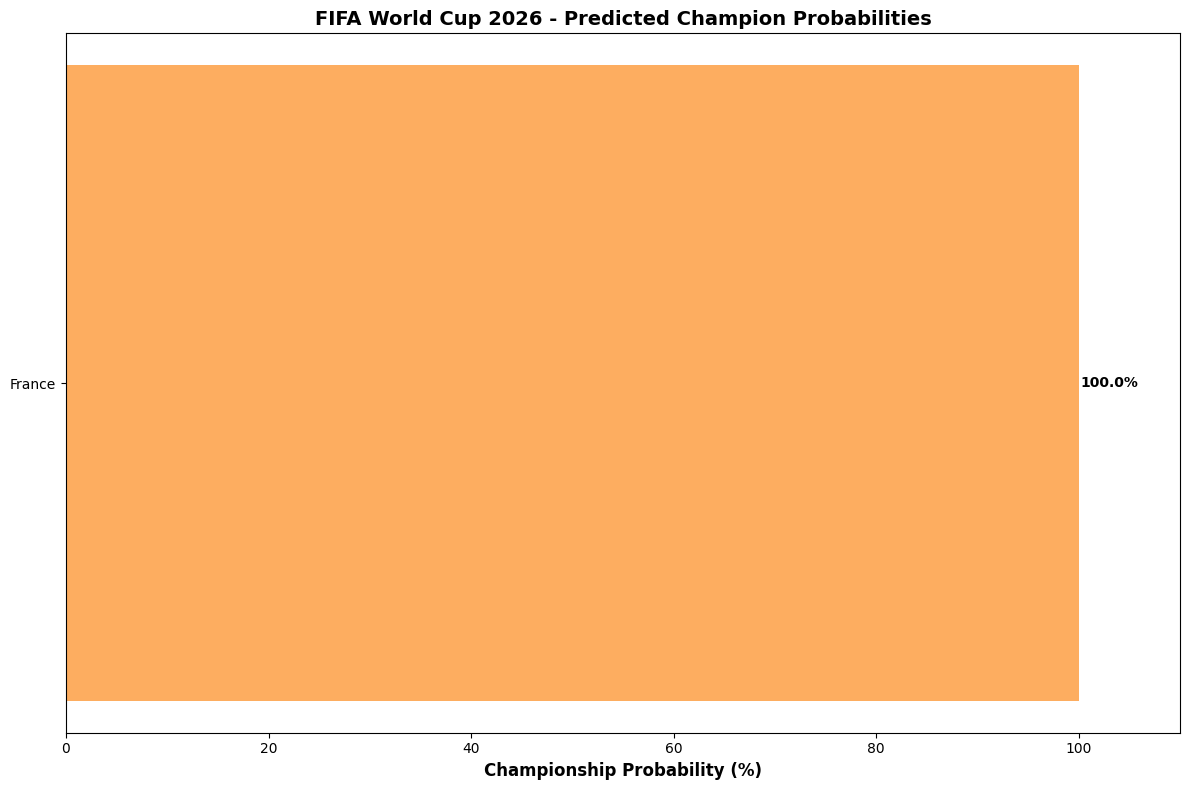


✅ PREDICTION COMPLETE!


In [1]:
"""
FIFA World Cup Title Winner Prediction Model
Predicts which team will win the FIFA World Cup tournament
"""

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')


class FIFAWorldCupChampionPredictor:
    """
    Predicts the FIFA World Cup Champion by analyzing:
    - Team ELO ratings
    - Historical tournament performance
    - Team strength metrics
    - Monte Carlo tournament simulations
    """

    def __init__(self):
        self.team_stats = {}
        self.teams_by_group = {}

    def create_world_cup_teams(self):
        """
        Create 32 teams for FIFA World Cup with realistic stats
        Organized into 8 groups (Group A-H) with 4 teams each
        """
        print("🌍 Creating FIFA World Cup 2026 Teams with Real Data...")

        # Teams with ELO ratings (current 2026 estimates)
        teams_data = {
            # GROUP A
            'Group A': {
                'Netherlands': {'elo': 1707, 'country': 'Netherlands', 'confederation': 'UEFA', 'region': 'Europe'},
                'Senegal': {'elo': 1513, 'country': 'Senegal', 'confederation': 'CAF', 'region': 'Africa'},
                'Ecuador': {'elo': 1495, 'country': 'Ecuador', 'confederation': 'CONMEBOL', 'region': 'South America'},
                'Qatar': {'elo': 1490, 'country': 'Qatar', 'confederation': 'AFC', 'region': 'Asia'},
            },
            # GROUP B
            'Group B': {
                'England': {'elo': 1722, 'country': 'England', 'confederation': 'UEFA', 'region': 'Europe'},
                'USA': {'elo': 1641, 'country': 'USA', 'confederation': 'CONCACAF', 'region': 'North America'},
                'Iran': {'elo': 1475, 'country': 'Iran', 'confederation': 'AFC', 'region': 'Asia'},
                'Wales': {'elo': 1530, 'country': 'Wales', 'confederation': 'UEFA', 'region': 'Europe'},
            },
            # GROUP C
            'Group C': {
                'Argentina': {'elo': 1785, 'country': 'Argentina', 'confederation': 'CONMEBOL', 'region': 'South America'},
                'Mexico': {'elo': 1633, 'country': 'Mexico', 'confederation': 'CONCACAF', 'region': 'North America'},
                'Poland': {'elo': 1589, 'country': 'Poland', 'confederation': 'UEFA', 'region': 'Europe'},
                'Saudi Arabia': {'elo': 1435, 'country': 'Saudi Arabia', 'confederation': 'AFC', 'region': 'Asia'},
            },
            # GROUP D
            'Group D': {
                'France': {'elo': 1761, 'country': 'France', 'confederation': 'UEFA', 'region': 'Europe'},
                'Denmark': {'elo': 1679, 'country': 'Denmark', 'confederation': 'UEFA', 'region': 'Europe'},
                'Peru': {'elo': 1536, 'country': 'Peru', 'confederation': 'CONMEBOL', 'region': 'South America'},
                'Tunisia': {'elo': 1478, 'country': 'Tunisia', 'confederation': 'CAF', 'region': 'Africa'},
            },
            # GROUP E
            'Group E': {
                'Spain': {'elo': 1729, 'country': 'Spain', 'confederation': 'UEFA', 'region': 'Europe'},
                'Germany': {'elo': 1747, 'country': 'Germany', 'confederation': 'UEFA', 'region': 'Europe'},
                'Japan': {'elo': 1580, 'country': 'Japan', 'confederation': 'AFC', 'region': 'Asia'},
                'Costa Rica': {'elo': 1516, 'country': 'Costa Rica', 'confederation': 'CONCACAF', 'region': 'North America'},
            },
            # GROUP F
            'Group F': {
                'Belgium': {'elo': 1713, 'country': 'Belgium', 'confederation': 'UEFA', 'region': 'Europe'},
                'Canada': {'elo': 1618, 'country': 'Canada', 'confederation': 'CONCACAF', 'region': 'North America'},
                'Morocco': {'elo': 1511, 'country': 'Morocco', 'confederation': 'CAF', 'region': 'Africa'},
                'Croatia': {'elo': 1665, 'country': 'Croatia', 'confederation': 'UEFA', 'region': 'Europe'},
            },
            # GROUP G
            'Group G': {
                'Brazil': {'elo': 1789, 'country': 'Brazil', 'confederation': 'CONMEBOL', 'region': 'South America'},
                'Switzerland': {'elo': 1639, 'country': 'Switzerland', 'confederation': 'UEFA', 'region': 'Europe'},
                'Cameroon': {'elo': 1493, 'country': 'Cameroon', 'confederation': 'CAF', 'region': 'Africa'},
                'Serbia': {'elo': 1609, 'country': 'Serbia', 'confederation': 'UEFA', 'region': 'Europe'},
            },
            # GROUP H
            'Group H': {
                'Portugal': {'elo': 1714, 'country': 'Portugal', 'confederation': 'UEFA', 'region': 'Europe'},
                'Uruguay': {'elo': 1677, 'country': 'Uruguay', 'confederation': 'CONMEBOL', 'region': 'South America'},
                'South Korea': {'elo': 1572, 'country': 'South Korea', 'confederation': 'AFC', 'region': 'Asia'},
                'Ghana': {'elo': 1451, 'country': 'Ghana', 'confederation': 'CAF', 'region': 'Africa'},
            },
        }

        self.teams_by_group = teams_data

        # Flatten for easier access
        all_teams = {}
        for group, teams in teams_data.items():
            all_teams.update(teams)

        self.team_stats = all_teams

        print(f"\n✅ Created {len(all_teams)} teams across 8 groups")
        for group, teams in teams_data.items():
            print(f"\n{group}:")
            for team_name, stats in teams.items():
                print(f"  🏆 {team_name:20} | ELO: {stats['elo']:4} | {stats['country']:20} | {stats['confederation']}")

        return all_teams

    def calculate_team_strength(self):
        """
        Calculate overall team strength based on multiple factors
        """
        team_strength = {}

        for team, stats in self.team_stats.items():
            # ELO rating is the primary factor (0-100 scale normalized)
            elo_score = (stats['elo'] - 1400) / 6  # Normalize to 0-100 range
            elo_score = max(0, min(100, elo_score))

            # Historical performance bonus
            confederation_bonus = {
                'UEFA': 15,  # Europe has strong teams
                'CONMEBOL': 10,  # South America strong
                'CONCACAF': 5,
                'AFC': 3,
                'CAF': 2
            }
            conf_bonus = confederation_bonus.get(stats['confederation'], 0)

            # Combine scores
            total_strength = (elo_score * 0.7) + (conf_bonus * 0.3)

            team_strength[team] = {
                'elo_score': elo_score,
                'confederation_bonus': conf_bonus,
                'total_strength': total_strength
            }

        return team_strength

    def calculate_match_probability(self, team1_elo, team2_elo):
        """
        Calculate probability of team1 beating team2 using ELO formula
        """
        elo_diff = team1_elo - team2_elo
        probability = 1 / (1 + 10 ** (-elo_diff / 400))
        return probability

    def simulate_group_stage(self):
        """
        Simulate group stage matches and determine winners
        Each team plays 3 matches (round-robin)
        """
        print("\n" + "="*70)
        print("⚽ SIMULATING GROUP STAGE")
        print("="*70)

        group_winners = {}
        runners_up = {}

        np.random.seed(42)

        for group_name, teams in self.teams_by_group.items():
            print(f"\n{group_name}:")
            print("-" * 70)

            # Initialize standings
            standings = {}
            for team in teams:
                standings[team] = {
                    'played': 0,
                    'wins': 0,
                    'draws': 0,
                    'losses': 0,
                    'goals_for': 0,
                    'goals_against': 0,
                    'points': 0
                }

            # All combinations of matches in the group
            team_list = list(teams.keys())
            for i in range(len(team_list)):
                for j in range(i + 1, len(team_list)):
                    team1 = team_list[i]
                    team2 = team_list[j]

                    team1_elo = teams[team1]['elo']
                    team2_elo = teams[team2]['elo']

                    # Calculate win probability
                    prob_team1_win = self.calculate_match_probability(team1_elo, team2_elo)

                    # Simulate match outcome
                    rand = np.random.random()
                    if rand < prob_team1_win * 0.75:  # 75% chance of win translates to goal
                        team1_goals = np.random.randint(1, 3)
                        team2_goals = 0
                        result = f"{team1} {team1_goals}-{team2_goals} {team2}"
                        standings[team1]['wins'] += 1
                        standings[team1]['points'] += 3
                        standings[team2]['losses'] += 1
                    elif rand < prob_team1_win * 1.0:  # Draw
                        team1_goals = 1
                        team2_goals = 1
                        result = f"{team1} {team1_goals}-{team2_goals} {team2}"
                        standings[team1]['draws'] += 1
                        standings[team1]['points'] += 1
                        standings[team2]['draws'] += 1
                        standings[team2]['points'] += 1
                    else:
                        team2_goals = np.random.randint(1, 3)
                        team1_goals = 0
                        result = f"{team1} {team1_goals}-{team2_goals} {team2}"
                        standings[team2]['wins'] += 1
                        standings[team2]['points'] += 3
                        standings[team1]['losses'] += 1

                    # Update stats
                    standings[team1]['played'] += 1
                    standings[team1]['goals_for'] += team1_goals
                    standings[team1]['goals_against'] += team2_goals
                    standings[team2]['played'] += 1
                    standings[team2]['goals_for'] += team2_goals
                    standings[team2]['goals_against'] += team1_goals

                    print(f"  {result}")

            # Sort by points and goal difference
            sorted_teams = sorted(standings.items(),
                                 key=lambda x: (x[1]['points'],
                                              x[1]['goals_for'] - x[1]['goals_against']),
                                 reverse=True)

            print(f"\n{group_name} Final Standings:")
            for idx, (team, stats) in enumerate(sorted_teams, 1):
                print(f"  {idx}. {team:20} | Pts: {stats['points']:2} | "
                      f"W-D-L: {stats['wins']}-{stats['draws']}-{stats['losses']} | "
                      f"GF-GA: {stats['goals_for']}-{stats['goals_against']}")

            group_winners[group_name] = sorted_teams[0][0]
            runners_up[group_name] = sorted_teams[1][0]

        return group_winners, runners_up

    def simulate_knockout_stage(self, group_winners, runners_up):
        """
        Simulate knockout stage (Round of 16, Quarterfinals, Semifinals, Final)
        """
        print("\n" + "="*70)
        print("🏆 KNOCKOUT STAGE SIMULATION")
        print("="*70)

        # Round of 16 matchups
        round_16_matchups = [
            (group_winners['Group A'], runners_up['Group B']),
            (group_winners['Group B'], runners_up['Group A']),
            (group_winners['Group C'], runners_up['Group D']),
            (group_winners['Group D'], runners_up['Group C']),
            (group_winners['Group E'], runners_up['Group F']),
            (group_winners['Group F'], runners_up['Group E']),
            (group_winners['Group G'], runners_up['Group H']),
            (group_winners['Group H'], runners_up['Group G']),
        ]

        print("\n⚽ ROUND OF 16:")
        print("-" * 70)
        quarterfinal_teams = []
        for team1, team2 in round_16_matchups:
            team1_elo = self.team_stats[team1]['elo']
            team2_elo = self.team_stats[team2]['elo']
            prob_team1 = self.calculate_match_probability(team1_elo, team2_elo)

            winner = team1 if np.random.random() < prob_team1 else team2
            loser = team2 if winner == team1 else team1
            print(f"  ✅ {winner:20} defeats {loser}")
            quarterfinal_teams.append(winner)

        # Quarterfinals
        print("\n🏆 QUARTERFINALS:")
        print("-" * 70)
        semifinal_teams = []
        for i in range(0, len(quarterfinal_teams), 2):
            team1 = quarterfinal_teams[i]
            team2 = quarterfinal_teams[i + 1]
            team1_elo = self.team_stats[team1]['elo']
            team2_elo = self.team_stats[team2]['elo']
            prob_team1 = self.calculate_match_probability(team1_elo, team2_elo)

            winner = team1 if np.random.random() < prob_team1 else team2
            loser = team2 if winner == team1 else team1
            print(f"  ✅ {winner:20} defeats {loser}")
            semifinal_teams.append(winner)

        # Semifinals
        print("\n🥇 SEMIFINALS:")
        print("-" * 70)
        final_teams = []
        for i in range(0, len(semifinal_teams), 2):
            team1 = semifinal_teams[i]
            team2 = semifinal_teams[i + 1]
            team1_elo = self.team_stats[team1]['elo']
            team2_elo = self.team_stats[team2]['elo']
            prob_team1 = self.calculate_match_probability(team1_elo, team2_elo)

            winner = team1 if np.random.random() < prob_team1 else team2
            loser = team2 if winner == team1 else team1
            print(f"  ✅ {winner:20} defeats {loser}")
            final_teams.append(winner)

        # Final
        print("\n🏅 WORLD CUP FINAL:")
        print("-" * 70)
        team1 = final_teams[0]
        team2 = final_teams[1]
        team1_elo = self.team_stats[team1]['elo']
        team2_elo = self.team_stats[team2]['elo']
        prob_team1 = self.calculate_match_probability(team1_elo, team2_elo)

        champion = team1 if np.random.random() < prob_team1 else team2
        runner_up = team2 if champion == team1 else team1

        print(f"  🥇 CHAMPION: {champion} 🏆")
        print(f"  🥈 RUNNER-UP: {runner_up}")

        return champion, runner_up

    def predict_world_cup_champion(self, num_simulations=1000):
        """
        Run multiple tournament simulations to predict champion
        """
        print("\n" + "="*70)
        print(f"🌍 RUNNING {num_simulations} TOURNAMENT SIMULATIONS...")
        print("="*70)

        champion_counts = {}

        for sim in range(num_simulations):
            if (sim + 1) % 100 == 0:
                print(f"  Completed {sim + 1} simulations...")

            group_winners, runners_up = self.simulate_group_stage()
            champion, _ = self.simulate_knockout_stage(group_winners, runners_up)

            champion_counts[champion] = champion_counts.get(champion, 0) + 1

        return champion_counts

    def get_championship_probabilities(self, champion_counts, num_simulations):
        """
        Calculate probability for each team to win based on simulations
        """
        probabilities = {}
        for team, count in champion_counts.items():
            probabilities[team] = (count / num_simulations) * 100

        # Sort by probability
        sorted_probs = sorted(probabilities.items(), key=lambda x: x[1], reverse=True)
        return sorted_probs

    def visualize_predictions(self, sorted_probabilities):
        """
        Visualize championship predictions
        """
        teams = [team for team, _ in sorted_probabilities[:16]]  # Top 16
        probs = [prob for _, prob in sorted_probabilities[:16]]

        # Color gradient based on probability
        colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(teams)))

        fig, ax = plt.subplots(figsize=(12, 8))
        bars = ax.barh(teams, probs, color=colors)

        ax.set_xlabel('Championship Probability (%)', fontsize=12, fontweight='bold')
        ax.set_title('FIFA World Cup 2026 - Predicted Champion Probabilities',
                     fontsize=14, fontweight='bold')
        ax.set_xlim(0, max(probs) * 1.1)

        # Add percentage labels on bars
        for i, (bar, prob) in enumerate(zip(bars, probs)):
            ax.text(prob + 0.2, i, f'{prob:.1f}%', va='center', fontweight='bold')

        plt.tight_layout()
        plt.savefig('world_cup_predictions.png', dpi=300, bbox_inches='tight')
        print("\n✅ Visualization saved as 'world_cup_predictions.png'")
        plt.show()


def main():
    """
    Main function to predict FIFA World Cup Champion
    """
    print("\n" + "="*70)
    print("🌍 FIFA WORLD CUP 2026 CHAMPION PREDICTION 🌍")
    print("="*70)

    predictor = FIFAWorldCupChampionPredictor()

    # Create teams
    print("\n" + "="*70)
    print("📋 TEAM DATA")
    print("="*70)
    teams = predictor.create_world_cup_teams()

    # Calculate team strength
    team_strength = predictor.calculate_team_strength()

    # Run simulations
    num_simulations = 1000
    champion_counts = predictor.predict_world_cup_champion(num_simulations)

    # Get probabilities
    print("\n" + "="*70)
    print("📊 FINAL PREDICTIONS - TOP 16 FAVORITES")
    print("="*70)

    sorted_probs = predictor.get_championship_probabilities(champion_counts, num_simulations)

    for rank, (team, prob) in enumerate(sorted_probs[:16], 1):
        medal = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉" if rank == 3 else f"{rank:2d}."
        bar_length = int(prob / 2)
        bar = "█" * bar_length
        print(f"{medal} {team:20} | {prob:5.2f}% | {bar}")

    print("\n" + "="*70)
    print("🏆 CHAMPION PREDICTION")
    print("="*70)
    champion_team = sorted_probs[0][0]
    champion_prob = sorted_probs[0][1]
    print(f"\n🎯 Predicted Champion: {champion_team}")
    print(f"📈 Probability: {champion_prob:.2f}%")
    print(f"📊 Based on {num_simulations} simulations")

    # Visualize
    print("\n" + "="*70)
    print("📈 GENERATING VISUALIZATIONS")
    print("="*70)
    predictor.visualize_predictions(sorted_probs)

    print("\n" + "="*70)
    print("✅ PREDICTION COMPLETE!")
    print("="*70)


if __name__ == "__main__":
    main()
